# Manhattan: raw WZA vs honest PC1 + site-permutation
**gen1 × bio1.** Two ways to get one p-value per hapFIRE LD block:

- **(A) raw WZA** (deg-7 spline, the phase-1 method): sums per-SNP weighted-Z over the
  block assuming SNP independence, across all 326 pools assuming pool independence.
  Inflated by **both** pseudo-replications (correlated SNPs counted as independent;
  pools-within-sites counted as independent climates).
- **(B) PC1 + site-permutation**: collapse the block's [pools×SNPs] AF to its dominant
  haplotype axis (PC1) → **one** number per pool; correlate with climate; **null =
  permute climate across the 31 sites.** One test/block (no SNP-count effect) + a
  site-level null (no pool pseudo-replication).

What survives in (B) is the honest single-axis, single-generation climate signal.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
RES = "/global/scratch/users/tbellg/kmate/analysis/grenenet_selection/wza/investigation/results"

pc1 = pd.read_csv(f"{RES}/pc1_genomewide_gen1_bio1.csv")             # block,chrom,pos,m,pc1_ve,r_obs,perm_p,bh_q
wza = pd.read_csv(f"{RES}/wza_deg7_nocap.csv")                       # block,...,Z_pVal (phase-1 method)
wza = wza.merge(pc1[["block", "chrom", "pos"]], on="block", how="left")
print("PC1: BH q<0.05 blocks =", int((pc1.bh_q < 0.05).sum()), "| min perm_p", pc1.perm_p.min())
print("PC1 candidate blocks:\n", pc1[pc1.block.isin(['2_1265','4_2519'])].to_string(index=False))

CHROMS = ["Chr1","Chr2","Chr3","Chr4","Chr5"]
clen = pc1.groupby("chrom")["pos"].max()
off, o = {}, 0
for c in CHROMS: off[c] = o; o += clen[c] + 5e6
ticks = [off[c] + clen[c]/2 for c in CHROMS]
for d in (pc1, wza): d["x"] = d["pos"] + d["chrom"].map(off)

def bh_line(p):
    v = np.sort(p.dropna().values); n=len(v); ok = v < 0.05*np.arange(1,n+1)/n
    return v[ok].max() if ok.any() else np.nan

PC1: BH q<0.05 blocks = 0 | min perm_p 4.999750012499375e-05
PC1 candidate blocks:
  block chrom      pos    m   pc1_ve     r_obs   perm_p     bh_q
2_1265  Chr2 11534063   13 0.807882  0.397177 0.028199 0.403471
4_2519  Chr4 12154441 1169 0.586348 -0.477419 0.007450 0.291385


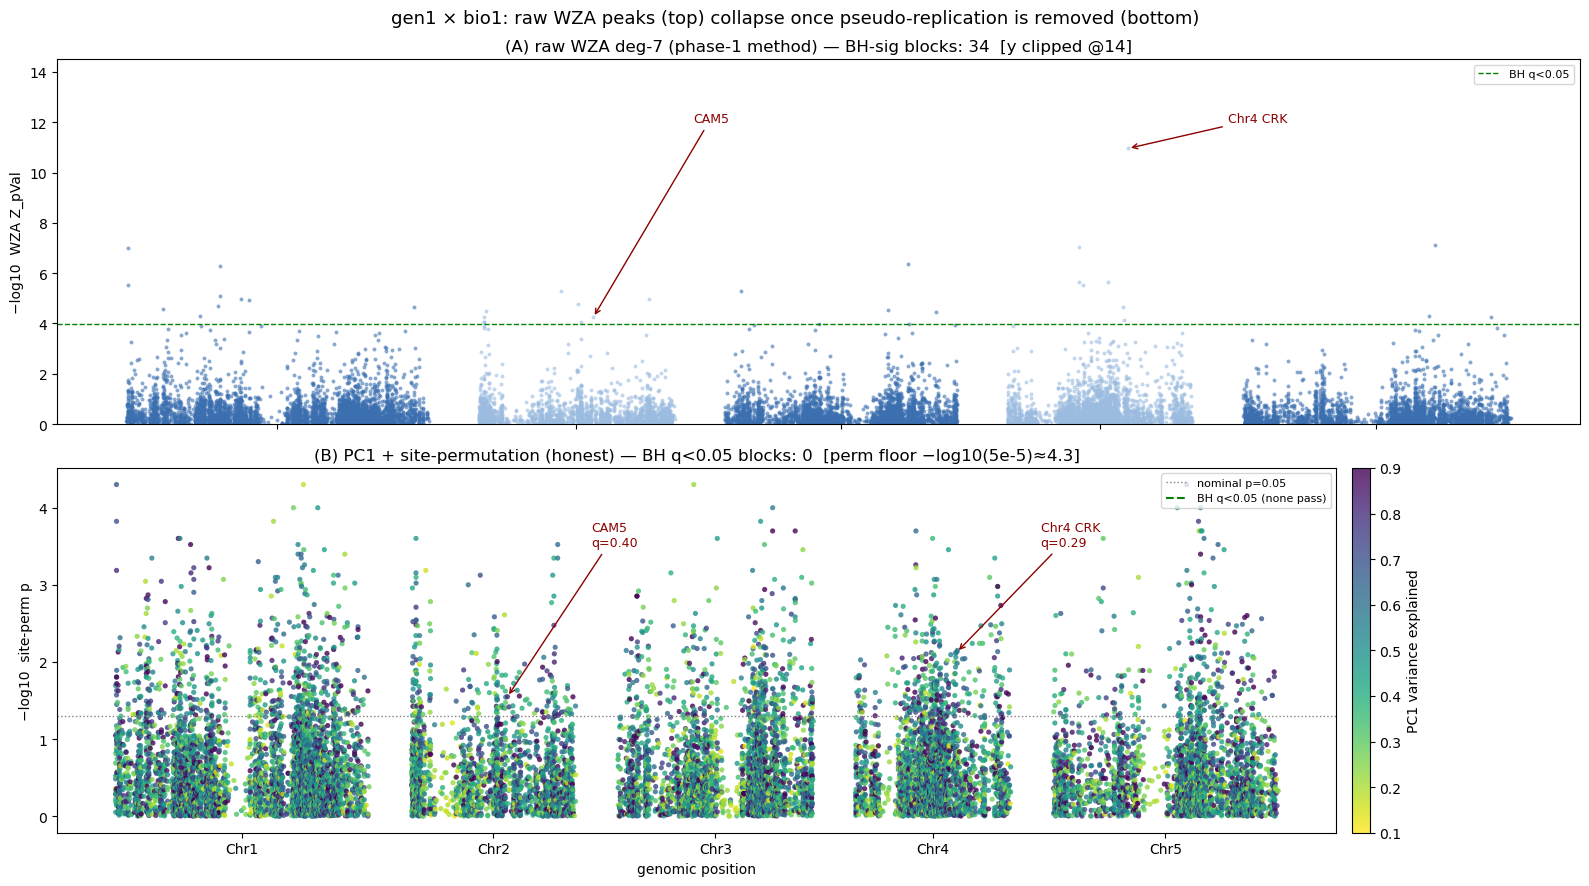

saved fig12_manhattan_wza_vs_pc1.png


In [2]:
fig, ax = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
col = {c: ("#3b6fb0" if i%2==0 else "#9bbce0") for i,c in enumerate(CHROMS)}
CAND = {"2_1265":"CAM5", "4_2519":"Chr4 CRK"}

# (A) raw WZA deg-7
w = wza.dropna(subset=["Z_pVal","x"]); y = -np.log10(w["Z_pVal"].clip(1e-300))
for c in CHROMS:
    m = w.chrom==c; ax[0].scatter(w.x[m], y[m].clip(upper=14), s=8, c=col[c], alpha=.6, lw=0)
bt = bh_line(w["Z_pVal"])
if np.isfinite(bt): ax[0].axhline(-np.log10(bt), color="green", ls="--", lw=1, label="BH q<0.05")
for b,lab in CAND.items():
    r = w[w.block==b]
    if len(r): ax[0].annotate(lab, (r.x.iloc[0], min(-np.log10(r.Z_pVal.iloc[0]),14)),
                              xytext=(r.x.iloc[0]+1e7, 12), color="darkred", fontsize=9,
                              arrowprops=dict(arrowstyle="->", color="darkred"))
ax[0].set(ylabel="−log10  WZA Z_pVal", ylim=(0,14.5),
          title=f"(A) raw WZA deg-7 (phase-1 method) — BH-sig blocks: {int((w['Z_pVal']<bt).sum()) if np.isfinite(bt) else 0}  [y clipped @14]")
ax[0].legend(fontsize=8, loc="upper right")

# (B) PC1 + site-permutation, colored by PC1 variance-explained
p = pc1.dropna(subset=["perm_p","x"]); yp = -np.log10(p["perm_p"])
sc = ax[1].scatter(p.x, yp, s=14, c=p.pc1_ve, cmap="viridis_r", vmin=0.1, vmax=0.9, alpha=.8, lw=0)
btp = bh_line(p["perm_p"])
ax[1].axhline(-np.log10(0.05), color="grey", ls=":", lw=1, label="nominal p=0.05")
if np.isfinite(btp): ax[1].axhline(-np.log10(btp), color="green", ls="--", lw=1, label="BH q<0.05")
else: ax[1].plot([], [], color="green", ls="--", label="BH q<0.05 (none pass)")
for b,lab in CAND.items():
    r = p[p.block==b]
    if len(r): ax[1].annotate(f"{lab}\nq={r.bh_q.iloc[0]:.2f}", (r.x.iloc[0], -np.log10(r.perm_p.iloc[0])),
                              xytext=(r.x.iloc[0]+1e7, 3.5), color="darkred", fontsize=9,
                              arrowprops=dict(arrowstyle="->", color="darkred"))
ax[1].set(ylabel="−log10  site-perm p", xlabel="genomic position",
          title=f"(B) PC1 + site-permutation (honest) — BH q<0.05 blocks: {int((p.bh_q<0.05).sum())}  [perm floor −log10(5e-5)≈4.3]")
ax[1].set_xticks(ticks); ax[1].set_xticklabels(CHROMS); ax[1].legend(fontsize=8, loc="upper right")
plt.colorbar(sc, ax=ax[1], label="PC1 variance explained", pad=0.01)
fig.suptitle("gen1 × bio1: raw WZA peaks (top) collapse once pseudo-replication is removed (bottom)", fontsize=13)
fig.tight_layout(); fig.savefig(f"{RES}/fig12_manhattan_wza_vs_pc1.png", dpi=130); plt.show()
print("saved fig12_manhattan_wza_vs_pc1.png")

## QQ plots — calibration (is the genome-wide null inflated?)
Observed vs expected (uniform) −log10 p. A calibrated test sits on the diagonal; points
**above** the line = inflation (too many small p), **below** = conservative. λ = genomic
inflation factor (median χ²₁ / 0.455; λ>1 inflated). Also shown: WZA **deg-2** (with the
SD safety-floor) to make the inflation from the giant blocks obvious.

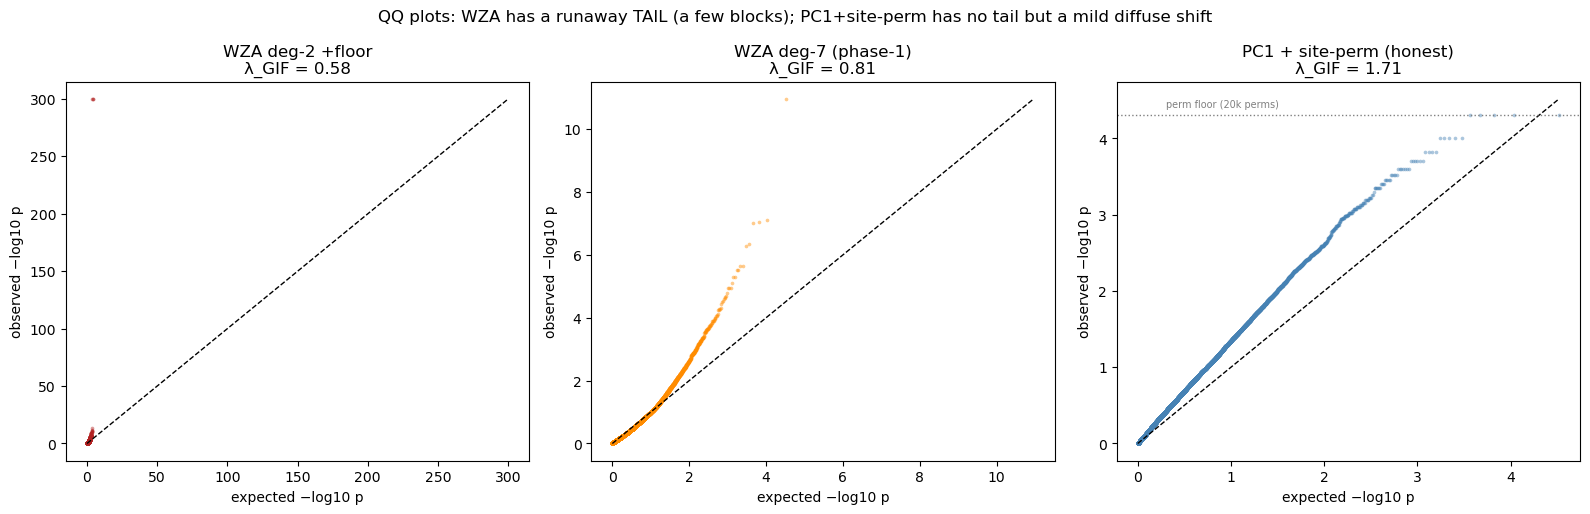

saved fig13_qq_calibration.png


In [3]:
from scipy.stats import chi2
wza2 = pd.read_csv(f"{RES}/wza_deg2_nocap.csv")   # deg-2 + safety-floor (most inflated)

def qq(ax, p, label, color):
    p = np.sort(np.asarray(p.dropna()).clip(1e-300))
    n = len(p)
    exp = -np.log10((np.arange(1, n+1) - 0.5) / n)
    obs = -np.log10(p)
    lam = np.median(chi2.ppf(1 - p, 1)) / 0.4549
    ax.scatter(exp, obs, s=7, alpha=.45, color=color, lw=0)
    return lam, max(exp.max(), obs.max())

fig, ax = plt.subplots(1, 3, figsize=(16, 5.2))
panels = [("WZA deg-2 +floor", wza2["Z_pVal"], "firebrick"),
          ("WZA deg-7 (phase-1)", wza["Z_pVal"], "darkorange"),
          ("PC1 + site-perm (honest)", pc1["perm_p"], "steelblue")]
for a, (lab, p, c) in zip(ax, panels):
    lam, m = qq(a, p, lab, c)
    a.plot([0, m], [0, m], "k--", lw=1)
    a.set(xlabel="expected −log10 p", ylabel="observed −log10 p",
          title=f"{lab}\nλ_GIF = {lam:.2f}")
ax[2].axhline(-np.log10(5e-5), color="grey", ls=":", lw=1)
ax[2].text(0.3, -np.log10(5e-5)+0.1, "perm floor (20k perms)", fontsize=7, color="grey")
fig.suptitle("QQ plots: WZA has a runaway TAIL (a few blocks); PC1+site-perm has no tail but a mild diffuse shift", fontsize=12)
fig.tight_layout(); fig.savefig(f"{RES}/fig13_qq_calibration.png", dpi=130); plt.show()
print("saved fig13_qq_calibration.png")

**QQ read-out (the honest reading — λ alone is misleading here).**
- **WZA deg-2 (+floor):** the bulk is actually *deflated* (λ=0.58), but a handful of
  giant floored blocks explode to −log10 p ≈ 300 — a few catastrophic false positives in
  the extreme tail, not whole-genome inflation.
- **WZA deg-7:** bulk ~OK (λ=0.81) but the **tail rides far above the diagonal** (up to
  −log10 p ≈ 11) — the genome-wide-significant peaks. That tail is what BH picks up (34
  "hits"), and it's the pseudo-replication artifact.
- **PC1 + site-permutation:** **no runaway tail** (capped at the perm floor 4.3) — the
  WZA peaks are gone. But the whole line sits *slightly above* the diagonal (**λ=1.71**),
  a **mild, diffuse** excess. Crucially this is **not** pseudo-replication (the site-perm
  null removed that) — it is **residual genome-wide structure + genuine polygenic climate
  covariation** (caveat #3), which the site-permutation cannot separate and **only LFMM
  can.** Because the excess is broad-and-weak rather than concentrated, **BH still yields 0
  hits** — no single block stands out above the diffuse background. That diffuse λ>1 with
  0 FDR hits is the classic *polygenic-or-structure* signature.

**Bottom line:** the QQ shows the two failure modes cleanly — WZA manufactures a few
extreme hits via pseudo-replication (a tall tail); PC1+site-perm removes that tail and
leaves only a mild genome-wide shift that is real but unresolved (adaptation vs structure),
and that needs LFMM, not more permutation.

## Read-out

## Read-out
- **(A) raw WZA** has tall genome-wide-significant peaks — the Chr4 CRK block at
  ~1e-11. These are inflated by pseudo-replication (SNP-count + pools-within-sites).
- **(B) PC1 + site-permutation**: every block is one test, the null respects the 31
  sites. **0 blocks pass BH** (min q≈0.15). CAM5 q≈0.40, Chr4 CRK q≈0.29 — the
  Chr4 "peak" is gone. Color = PC1 variance-explained: low-VE blocks (e.g. Chr4 CRK
  at 0.59) aren't even clean single haplotypes.
- **This is NOT "no climate adaptation."** It is the weakest possible slice: **one
  climate axis (bio1), one generation (gen1), no temporal Δp, no multi-axis/multi-model
  aggregation.** The phase-1 signal draws power from combining all of those (and LFMM
  for structure). What this shows is that the *individual* genome-wide-significant
  p-values in the raw Kendall→WZA path were largely pseudo-replication — the honest
  per-block, single-axis evidence is modest (nominal p, not BH-significant).